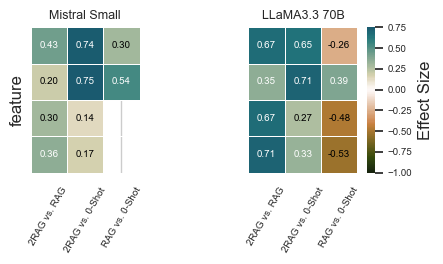

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import textwrap
import cmocean

# ------------------- Data Preparation -------------------
df_original = pd.DataFrame({
    "model": ["LLAMA 70B"]*4 + ["Mistral Small"]*4,
    "feature": ["score", "score_groundedness", "score_helpfulness", "score_depth"]*2,
    "2rag_rag": [0.67, 0.35, 0.67, 0.71, 0.43, 0.2, 0.3, 0.36],
    "2rag_zero_shot": [0.65, 0.71, 0.27, 0.33, 0.74, 0.75, 0.14, 0.17],
    "rag_zero_shot": [-0.26, 0.39, -0.48, -0.53, 0.3, 0.54, None, None]
})

# Rename feature labels for y-axis
rename_map = {
    "score": "score:overall",
    "score_groundedness": "score:groundedness",
    "score_helpfulness": "score:helpfulness",
    "score_depth": "score:depth"
}

def get_matrix(model_name):
    df_model = (df_original[df_original["model"] == model_name]
                .drop(columns="model")
                .set_index("feature"))
    return df_model.rename(index=rename_map)

df_mistral = get_matrix("Mistral Small")
df_llama = get_matrix("LLAMA 70B")

x_axis = ["2RAG vs. RAG", "2RAG vs. 0-Shot", "RAG vs. 0-Shot"]

# Scientific professional colormap
cmap = cmocean.cm.tarn
vmin, vmax = -1, 0.75

# ------------------- Annotation Function -------------------
def annotate_heatmap(ax, data, cmap):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]
            if not np.isnan(val):
                color = cmap((val - vmin) / (vmax - vmin))
                brightness = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
                text_color = "white" if brightness < 0.5 else "black"
                ax.text(j + 0.5, i + 0.5, f"{val:.2f}",
                        ha='center', va='center', color=text_color, fontsize=7)

# ------------------- Plot -------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(5, 2.8), sharey=True)

# --- Left Heatmap (Mistral) ---
sns.heatmap(df_mistral, center=0, cmap=cmap,
            xticklabels=x_axis, yticklabels=True,
            linewidths=0.5, linecolor='white',
            square=True, cbar=False,
            vmin=vmin, vmax=vmax, ax=axes[0])
annotate_heatmap(axes[0], df_mistral, cmap)
axes[0].set_yticks(np.arange(len(df_mistral.index)) + 0.5)
axes[0].set_yticklabels(df_mistral.index, rotation=0, fontsize=8)
axes[0].set_ylim(len(df_mistral.index), 0)
axes[0].set_title("Mistral Small", fontsize=9)
axes[0].set_xticklabels([textwrap.fill(x, 16) for x in x_axis],
                        rotation=60, ha="center", fontsize=7)

# --- Right Heatmap (LLaMA) ---
sns.heatmap(df_llama, center=0, cmap=cmap,
            xticklabels=x_axis, yticklabels=False,
            linewidths=0.5, linecolor='white',
            square=True, cbar_kws={'label': 'Effect Size'},
            vmin=vmin, vmax=vmax, ax=axes[1])
annotate_heatmap(axes[1], df_llama, cmap)
axes[1].set_xticklabels([textwrap.fill(x, 16) for x in x_axis],
                        rotation=60, ha="center", fontsize=7)
axes[1].set_title("LLaMA3.3 70B", fontsize=9)
axes[1].set_ylabel("")
# Colorbar font size
cbar = axes[1].collections[0].colorbar
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("heatmap_scientific_ice.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
pip install -qU cmocean